# Project – Wind Energy Prediction

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/git/https%3A%2F%2Fgitlab.in2p3.fr%2Fenergy4climate%2Fpublic%2Feducation%2Fmachine_learning_for_climate_and_energy/master?filepath=book%2Fnotebooks%2Fprojects.ipynb)

## Introduction

Since the Industrial Revolution, electricity has become deeply integrated into humanity’s daily life, establishing an essential foundation for the consolidation of our society. Energy has become ubiquitous in individuals’ lives, being used in various sectors such as industrial processes, transportation, heating, domestic comfort, among others. Thus, access to electricity is now considered an essential infrastructure service, serving as an indicator of a nation’s level of socio-economic development.

The energy sector is one of the main contributors to global greenhouse gas emissions, primarily due to the combustion of fossil fuels for electricity generation, transportation, and industrial processes. The Intergovernmental Panel on Climate Change (2025) indicate that annual global emissions exceed tens of gigatonnes of CO₂ equivalent, making the transformation of the energy system a central priority for climate change mitigation. Nevertheless, the global energy mix remains heavily dependent on non-renewable sources such as coal and natural gas, which, according to the International Energy Agency (2023), account for more than 58% of total energy supply. The extensive use of these sources has significant environmental consequences, as their combustion releases large amounts of atmospheric pollutants, contributing to global warming, air pollution, and other environmental impacts, including ocean acidification.

Although renewable energy has experienced notable growth in recent years, it historically accounted for a limited share of the global energy matrix. Data from the IEA show that the expansion of renewables accelerated mainly in recent decades, driven by technological advances, cost reductions, and the implementation of supportive public policies. In this context, wind energy stands out among renewable sources due to its high potential for expansion, technological maturity, and increasing economic competitiveness. According to Global Wind Energy Council, global installed wind power capacity has surpassed 1 terawatt, with annual capacity additions exceeding 100 gigawatts, positioning wind energy as a major driver of renewable electricity generation growth worldwide.

Currently, wind energy accounts for a significant share of global renewable electricity generation, contributing substantially to greenhouse gas emission reductions and to enhanced energy security. The continued expansion of both onshore and offshore wind power reinforces its strategic importance in the global energy transition. However, the increasing penetration of intermittent renewable sources also poses challenges to power system reliability. The blackout that occurred in Spain and Portugal in April of this year highlighted society’s strong dependence on electricity and exposed structural vulnerabilities in the Iberian Peninsula’s power grid, particularly regarding the management of renewable variability and the limited integration with the broader European electricity system \cite{rossi2025apagao}. This event clearly illustrates one of the main challenges associated with energy security in the transition toward more sustainable energy systems, underscoring the need for investments in infrastructure, regional integration, smart grids, and energy storage solutions.

In this context, the present report aims to evaluate wind energy generation using the machine learning methods learned during the course. To achieve this objective, the following steps will be carried out:

1 - Data analysis;

2 - Model training;

3 - Evaluation and interpretation of the results.

## 1. Data analysis

In [ ]:
# Functions needed
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
from sklearn.model_selection import cross_val_score

<Axes: xlabel='time'>

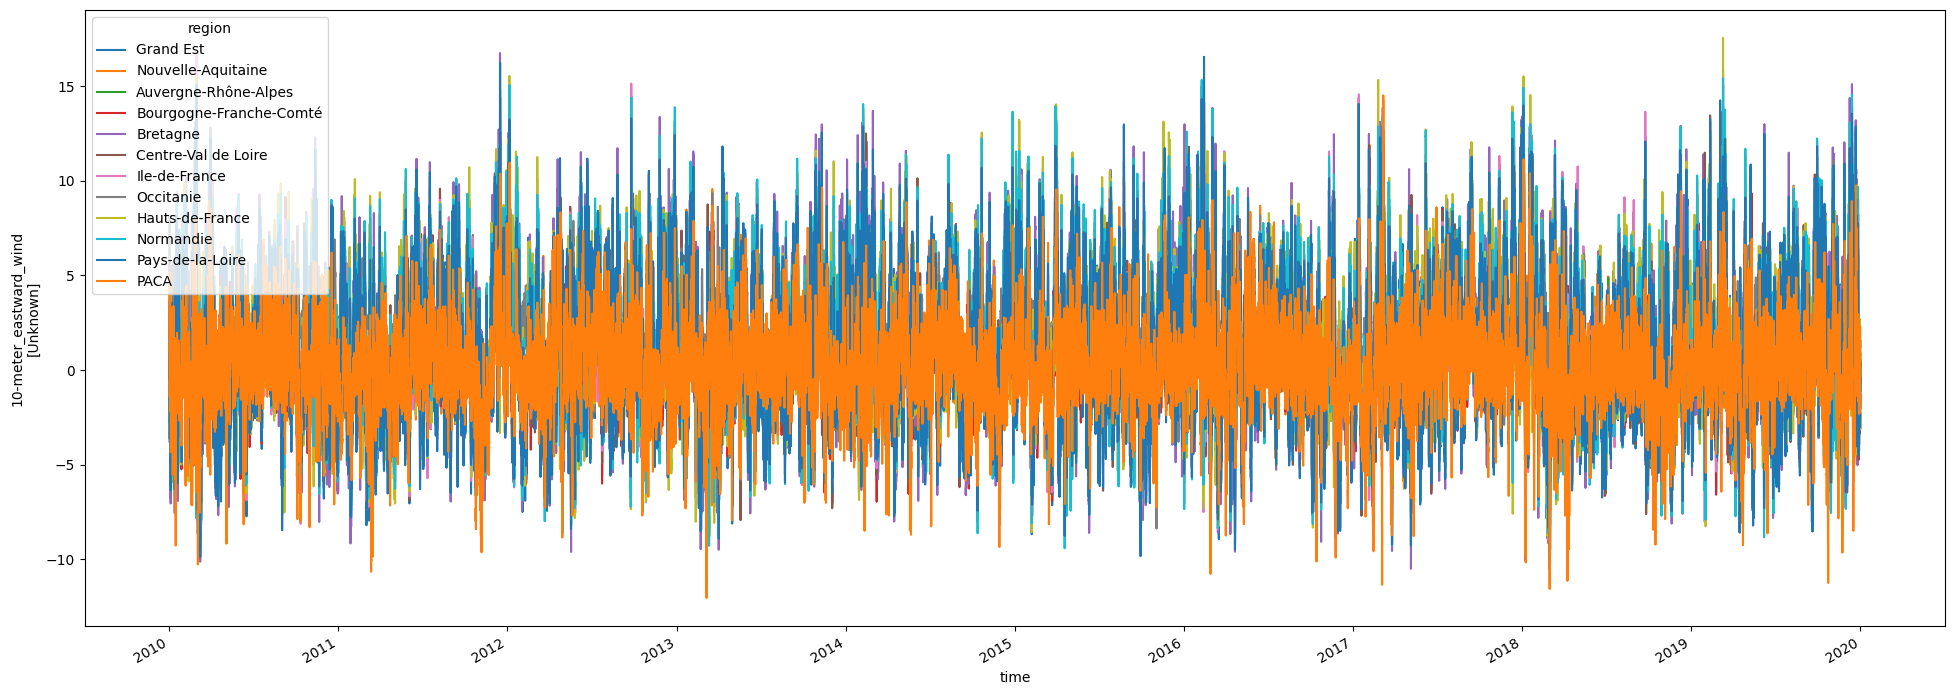

<Figure size 640x480 with 0 Axes>

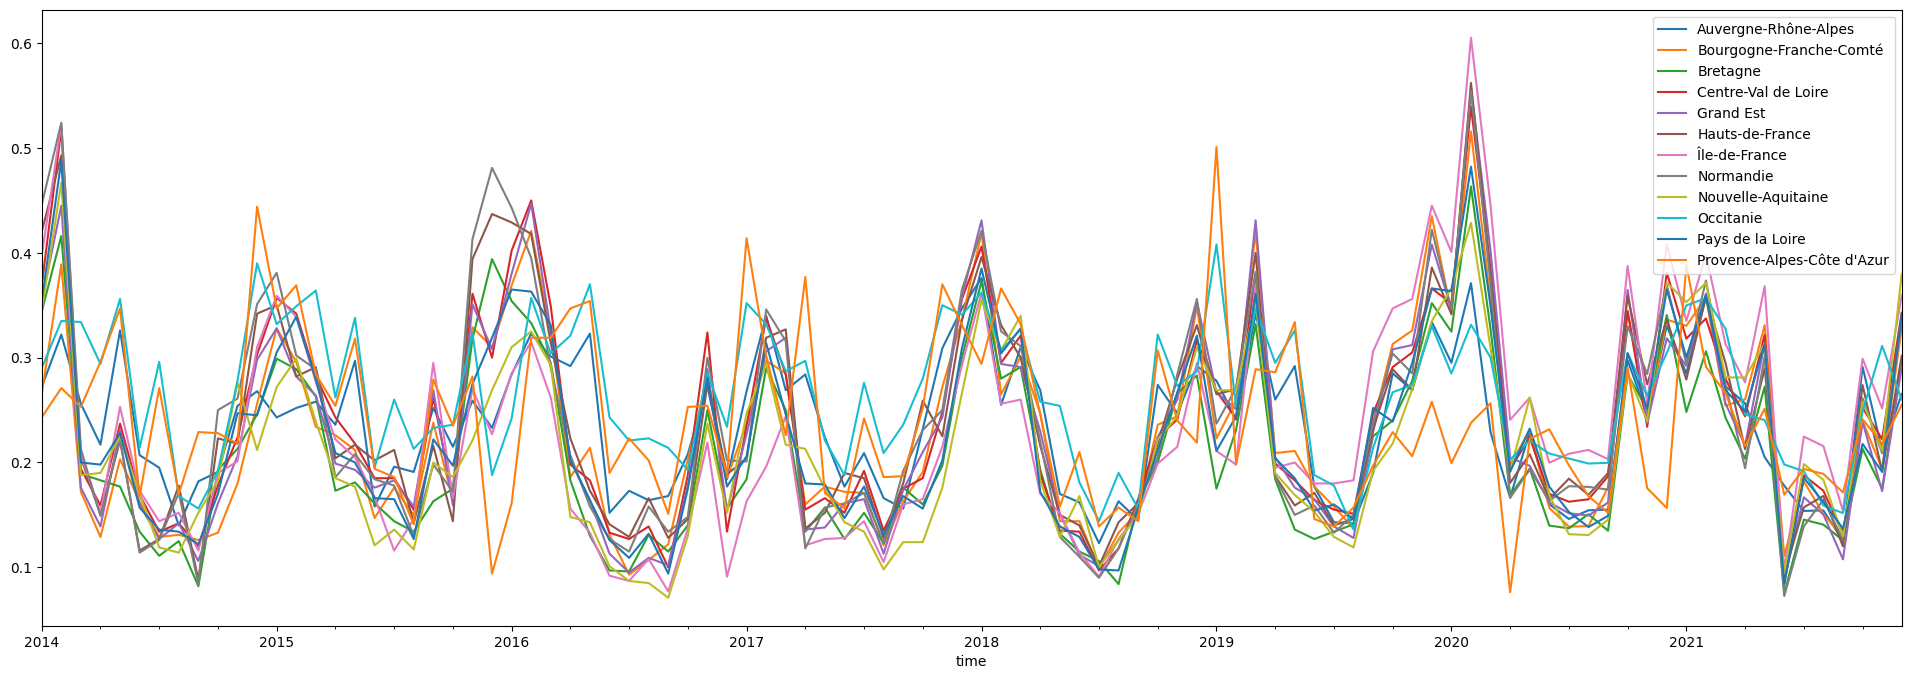

In [ ]:
# Directories where we saved the data
data_dir_energy = Path('data/projects/energy_france')
data_dir_climate = Path('data/projects/climate_france')
                        
# Template filenames
filename_mask = 'mask_datagouv_french_regions_merra2_Nx_France.nc'
filename_climate = 'merra2_area_selection_output_{}_merra2_2010-2019.nc'
filename_energy = 'reseaux_energies_{}.csv'

# Read and plot grid point-region mask
filepath_mask = Path(data_dir_climate, filename_mask)   
ds_mask = xr.load_dataset(filepath_mask)
da_mask = ds_mask['mask']
#plt.figure()
#plt.scatter(da_mask['lon'], da_mask['lat'], c=da_mask, cmap='Set1')

# Read a climate variable and plot its mean over time
variable_name = 'zonal_wind'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate = xr.load_dataset(filepath)[variable_name]
#plt.figure()
#plt.scatter(da_mask['lon'], da_mask['lat'], c=da_climate.mean('time'))

# Compute regional mean of climate variable and plot time series
da_climate_reg = da_climate.groupby(da_mask).mean().rename(mask='region')
da_climate_reg['region'] = ds_mask['region'].values
plt.figure(figsize=(24,8))
da_climate_reg.plot.line(x='time')

# Read energy variable and plot time series
variable_name = 'capacityfactor_wind-onshore'
filename = filename_energy.format(variable_name)
filepath = Path(data_dir_energy, filename)
df_energy = pd.read_csv(filepath, index_col=0, header=0, parse_dates=True)
plt.figure()
df_energy.plot(figsize=(24,8))

### 1.1. Selecting a location in metropolitan France and accessing climate variables of this location

In [ ]:
ds_mask = xr.load_dataset(data_dir_climate / filename_mask)
da_mask = ds_mask['mask']

variables = [
    'zonal_wind',
    'meridional_wind',
    'surface_temperature',
    'surface_downward_radiation',
    'surface_density',
    'surface_specific_humidity',
    'upper_zonal_wind',
    'upper_meridional_wind',
    'height_500',
]

In [ ]:
print("Avaiable regions in France: ")
da_climate_reg.region.values 

Avaiable regions in France: 


array(['Grand Est', 'Nouvelle-Aquitaine', 'Auvergne-Rhône-Alpes',
       'Bourgogne-Franche-Comté', 'Bretagne', 'Centre-Val de Loire',
       'Ile-de-France', 'Occitanie', 'Hauts-de-France', 'Normandie',
       'Pays-de-la-Loire', 'PACA'], dtype=object)

### 1.2. Selecting a region

In [ ]:
region_name = 'Ile-de-France'

In [ ]:
dfs = []

for var in variables:
    ds_var = xr.load_dataset(data_dir_climate / filename_climate.format(var))
    da_var = ds_var[var]                               # (time, lat, lon)

    da_var_reg = da_var.groupby(da_mask).mean().rename(mask='region')
    da_var_reg['region'] = ds_mask['region'].values    # same as prof

    # select region, convert to pandas Series, rename with variable name
    series_region = da_var_reg.sel(region=region_name).to_pandas()
    dfs.append(series_region.rename(var))

# Combine all variables side by side
df_all_variables = pd.concat(dfs, axis=1)

#df_all_variables.head()

In [ ]:
#df_energy['Île-de-France'].head()

### 1.3. Taking the monthly mean of the climate variables

In [ ]:
df_climate_monthly = df_all_variables.resample('MS').mean()
df_climate_monthly

,zonal_wind,meridional_wind,surface_temperature,surface_downward_radiation,surface_density,surface_specific_humidity,upper_zonal_wind,upper_meridional_wind,height_500
time,,,,,,,,,
2010-01-01,0.113088,-0.318379,272.273590,43.559608,1.277740,0.003301,0.350395,-0.394260,5431.350586
2010-02-01,1.520094,1.633788,275.193329,71.057159,1.250808,0.004014,2.226946,2.338912,5351.853027
2010-03-01,0.139313,0.279691,278.706116,141.006073,1.250952,0.004432,0.289097,0.467306,5505.052246
2010-04-01,-0.329032,-0.835640,283.016418,226.640015,1.233363,0.005089,-0.499806,-1.213971,5592.165039
2010-05-01,0.289953,-2.414946,284.744049,260.374359,1.221154,0.006000,0.313585,-3.403135,5595.019531
...,...,...,...,...,...,...,...,...,...
2019-08-01,1.408895,0.461117,293.096375,228.612228,1.186036,0.008507,1.932217,0.466144,5764.394531
2019-09-01,1.105618,-0.042446,289.145721,190.179108,1.206204,0.007319,1.497324,-0.181627,5749.764648
2019-10-01,1.522698,1.881359,285.335632,93.818886,1.215386,0.007387,2.270087,2.770181,5654.728027


### 1.4. Overlaping data of CP and climate variables

To ensure temporal consistency and properly prepare the data for analysis and modeling.

In [ ]:
df_climate_overlap = df_climate_monthly.loc['2014-01-01':'2019-12-01']
cf_overlap = df_energy['Île-de-France'].loc['2014-01-01':'2019-12-01']
cf_overlap = cf_overlap.rename('capacity_factor')
df_climate_overlap
cf_overlap

,zonal_wind,meridional_wind,surface_temperature,surface_downward_radiation,surface_density,surface_specific_humidity,upper_zonal_wind,upper_meridional_wind,height_500
time,,,,,,,,,
2014-01-01,1.457212,3.932577,278.326843,35.078514,1.239541,0.005184,2.201479,5.413025,5441.876465
2014-02-01,2.368809,4.987933,278.731354,66.375504,1.236099,0.004937,3.462634,6.872248,5407.690918
2014-03-01,0.433149,0.747019,281.533936,150.002029,1.237386,0.004942,0.462770,1.120855,5576.235352
2014-04-01,0.240969,0.179756,284.320435,203.017075,1.222223,0.006059,0.329754,0.195392,5591.039062
2014-05-01,1.160403,0.544363,285.875427,242.731064,1.216665,0.006797,1.622033,0.683228,5610.685547
...,...,...,...,...,...,...,...,...,...
2019-08-01,1.408895,0.461117,293.096375,228.612228,1.186036,0.008507,1.932217,0.466144,5764.394531
2019-09-01,1.105618,-0.042446,289.145721,190.179108,1.206204,0.007319,1.497324,-0.181627,5749.764648
2019-10-01,1.522698,1.881359,285.335632,93.818886,1.215386,0.007387,2.270087,2.770181,5654.728027


In [ ]:
df_dataset = df_climate_overlap.copy()
df_dataset['capacity_factor'] = cf_overlap
df_dataset = df_climate_overlap.join(cf_overlap, how='inner')
#df_dataset.head()

### 1.5. Evaluating linear correlation between the climate variables and CP value

To identify and quantify the linear relationships between climate variables and the capacity factor, supporting feature selection and model development.

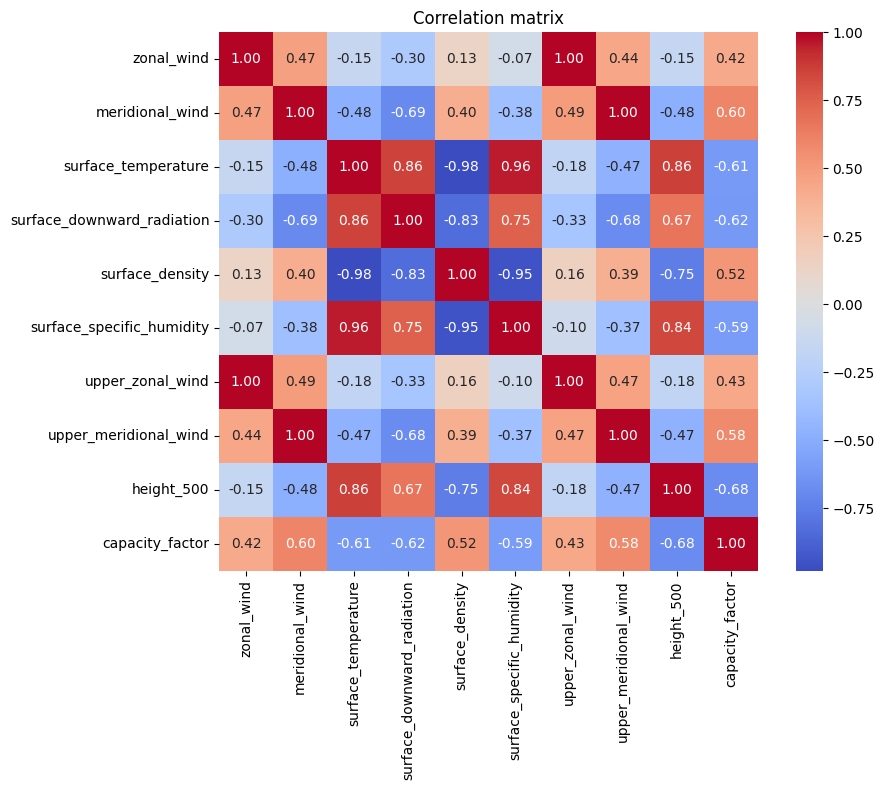

In [ ]:
corr = df_dataset.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


From the resulting correlation matrix, it is possible to observe that, according to the values in the last column, the least linearly correlated variable still presents a correlation coefficient of 0.42, indicating a moderate relationship rather than a weak one.

### 1.6. Data viewing

##### 1.6.1 All time

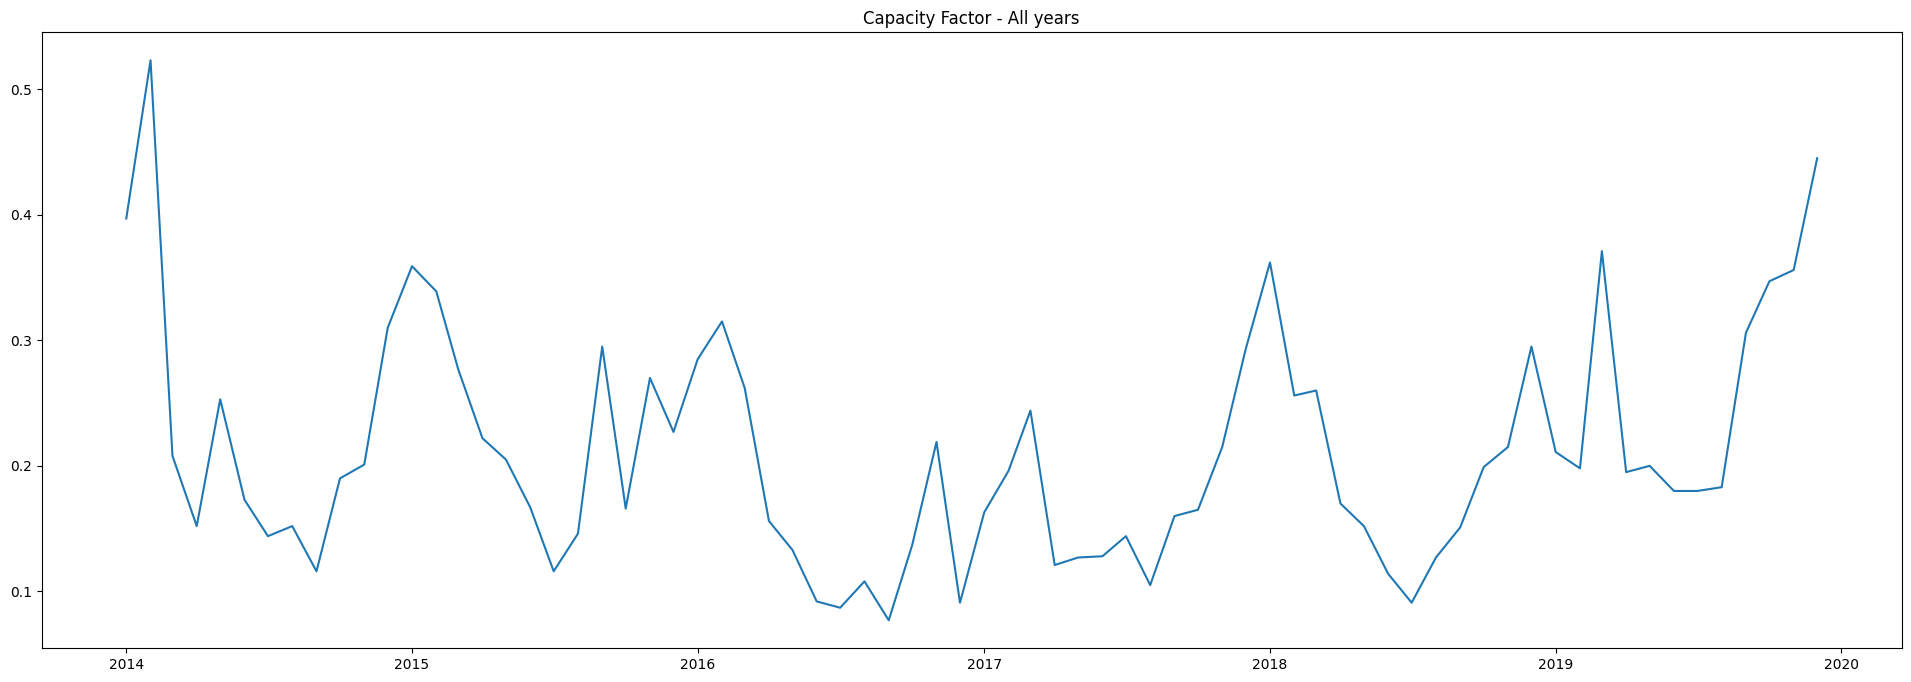

In [ ]:
plt.figure(figsize=(24,8))
plt.plot(cf_overlap)
plt.title("Capacity Factor - All years")
plt.show()

A clear seasonal pattern can be observed, with the capacity factor increasing during winter months and decreasing during summer periods, as expected due to seasonal wind variability.

#### 1.6.2 Years superposed

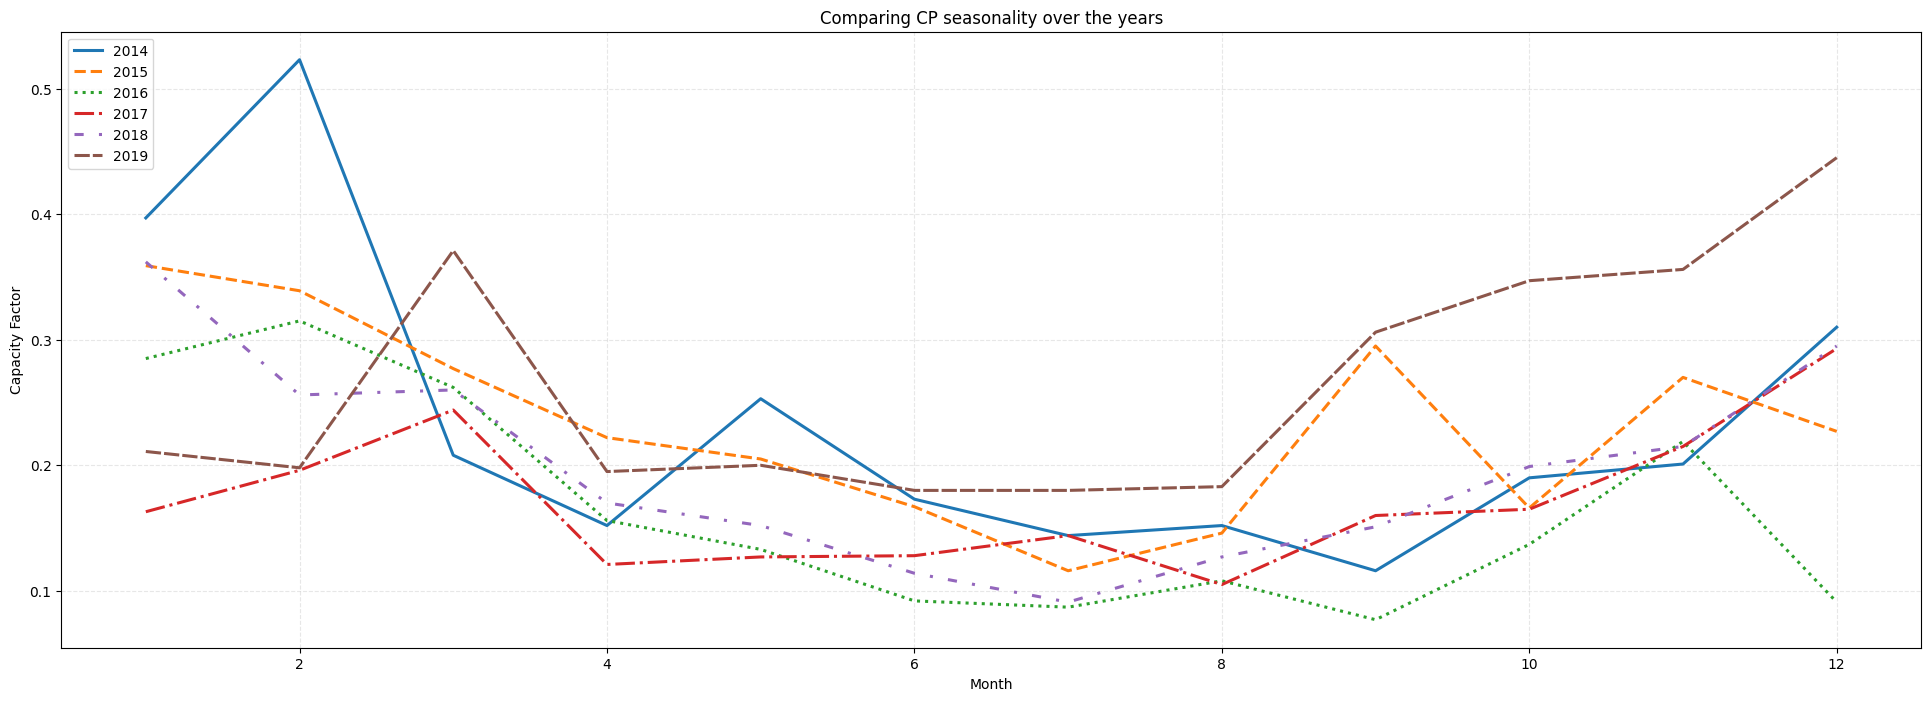

In [ ]:
plt.figure(figsize=(24,8))

line_styles = [
    '-',       
    '--',      
    ':',     
    '-.',     
    (0, (3, 5, 1, 5)), 
    (0, (5, 1))         
]

years = cf_overlap.index.year.unique()

for i, year in enumerate(years):
    serie = cf_overlap[str(year)]
    ls = line_styles[i % len(line_styles)]   # repete padrões se tiver mais de 6 anos
    
    plt.plot(
        serie.index.month,
        serie.values,
        label=str(year),
        linestyle=ls,
        linewidth=2.2
    )

plt.legend()
plt.xlabel("Month")
plt.ylabel("Capacity Factor")
plt.title("Comparing CP seasonality over the years")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


#### Some climate variables

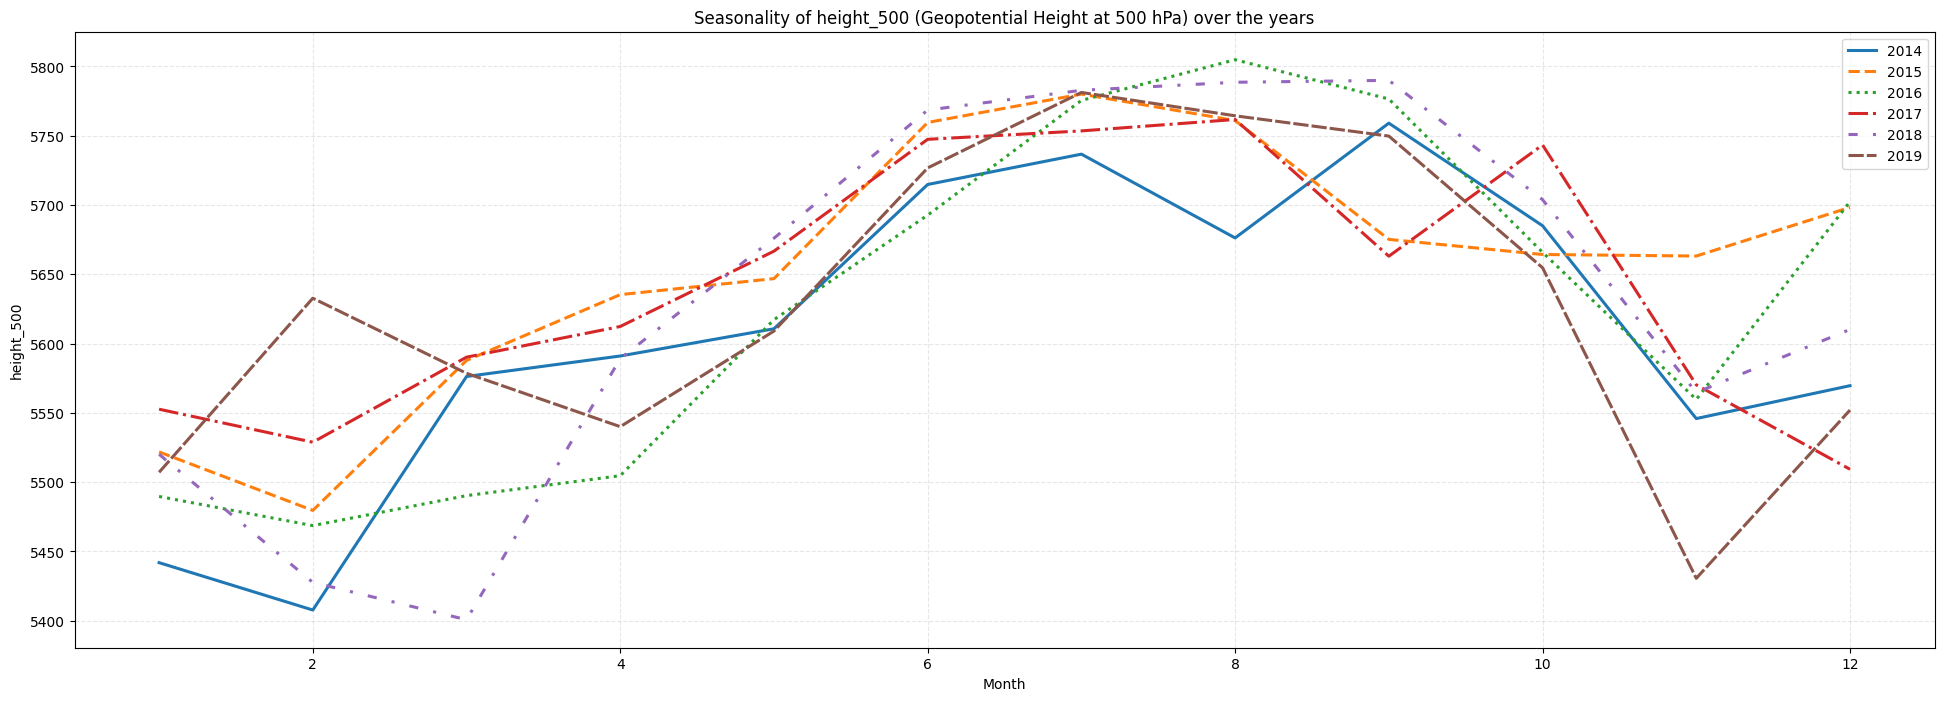

In [ ]:
plt.figure(figsize=(24,8))

line_styles = [
    '-',          
    '--',         
    ':',          
    '-.',         
    (0, (3, 5, 1, 5)),  
    (0, (5, 1))         
]


years = df_climate_overlap.index.year.unique()

for i, year in enumerate(years):
    serie = df_climate_overlap['height_500'].loc[str(year)]
    ls = line_styles[i % len(line_styles)]
    
    plt.plot(
        serie.index.month,
        serie.values,
        label=str(year),
        linestyle=ls,
        linewidth=2.2
    )

plt.legend()
plt.xlabel("Month")
plt.ylabel("height_500")
plt.title("Seasonality of height_500 (Geopotential Height at 500 hPa) over the years")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


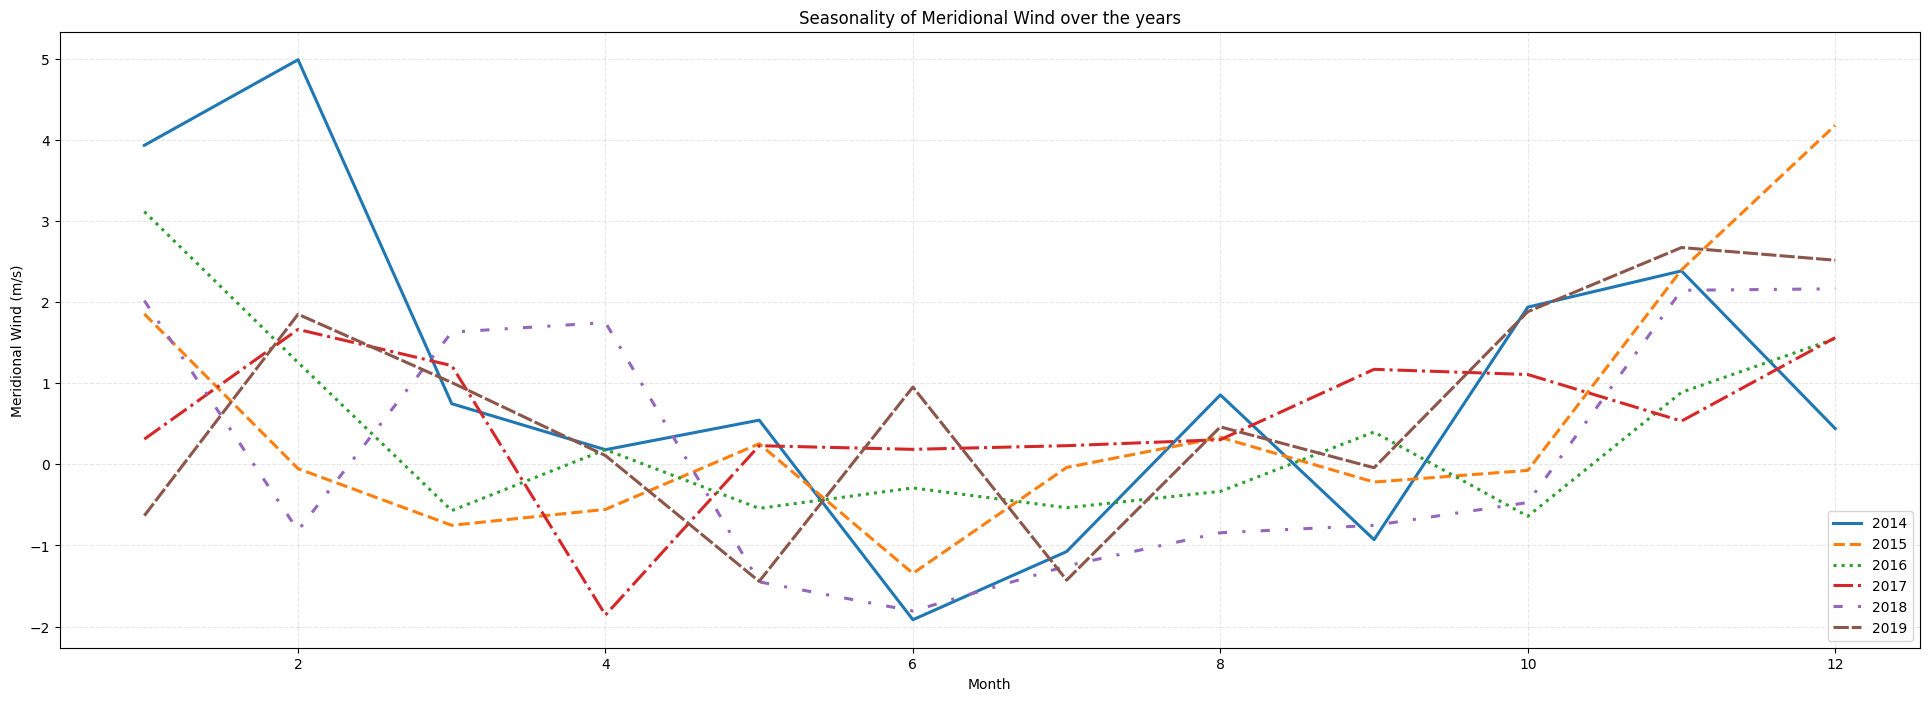

In [ ]:
plt.figure(figsize=(24,8))

line_styles = [
    '-',          
    '--',         
    ':',          
    '-.',         
    (0, (3, 5, 1, 5)),  
    (0, (5, 1))         
]

years = df_climate_overlap.index.year.unique()

for i, year in enumerate(years):
    serie = df_climate_overlap['meridional_wind'].loc[str(year)]
    ls = line_styles[i % len(line_styles)]
    
    plt.plot(
        serie.index.month,
        serie.values,
        label=str(year),
        linestyle=ls,
        linewidth=2.2
    )

plt.legend()
plt.xlabel("Month")
plt.ylabel("Meridional Wind (m/s)")
plt.title("Seasonality of Meridional Wind over the years")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


## 2. Model training

### 2.1. Linear Regression

We consider a linear regression model of the form:

$$
\hat{y} = X\beta + b
$$

where:

* (X) is the matrix of input features
* (y) is the target vector
* $\hat{y}$ is the model prediction
* $\beta$ is the vector of model coefficients, representing the contribution of each feature
* (b) is the intercept term

### 2.2. Loss Functions for Each Model

#### 2.2.1. Ordinary Least Squares (OLS)

OLS minimizes the sum of squared errors:

$$
\min_{\beta} ; |y - X\beta|_2^2
$$

This corresponds to finding the coefficients that best fit the data.

### 2.3. Linear regression

Assessing the predictive performance of the linear regression model using more recent data for validation.

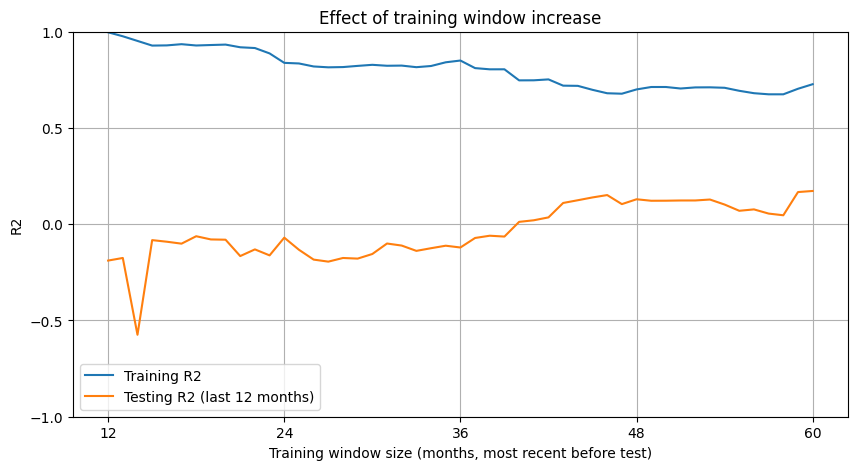

In [ ]:
df = df_dataset.copy()       
df = df.sort_index()

X_full = df.drop(columns=["capacity_factor"]).values
y_full = df["capacity_factor"].values

n_samples = len(df)
test_size = 12                    
test_start = n_samples - test_size 

n_train_max = test_start         

R2_train = np.zeros(n_train_max + 1)
R2_test  = np.zeros(n_train_max + 1)

for i in range(12, n_train_max + 1):

    train_start = test_start - i
    train_end   = test_start

    X_train_raw = X_full[train_start:train_end, :]
    y_train = y_full[train_start:train_end]

    X_test_raw  = X_full[test_start:, :]
    y_test = y_full[test_start:]

    mean = X_train_raw.mean(axis=0)
    std  = X_train_raw.std(axis=0)

    #std[std == 0] = 1e-8

    X_train = (X_train_raw - mean) / std
    X_test  = (X_test_raw  - mean) / std

    model = LinearRegression().fit(X_train, y_train)

    R2_train[i] = model.score(X_train, y_train)
    R2_test[i]  = model.score(X_test, y_test)


train_sizes = np.arange(12, n_train_max + 1)

plt.figure(figsize=(10,5))
plt.plot(train_sizes, R2_train[12:], label='Training R2')
plt.plot(train_sizes, R2_test[12:], label='Testing R2 (last 12 months)')
plt.xlabel('Training window size (months, most recent before test)')
plt.ylabel('R2')
plt.xticks([12, 24, 36, 48, 60])
plt.yticks([-1, -0.5, 0, 0.5, 1])
plt.ylim(-1, 1)
plt.title('Effect of training window increase')
plt.legend()
plt.grid()
plt.show()

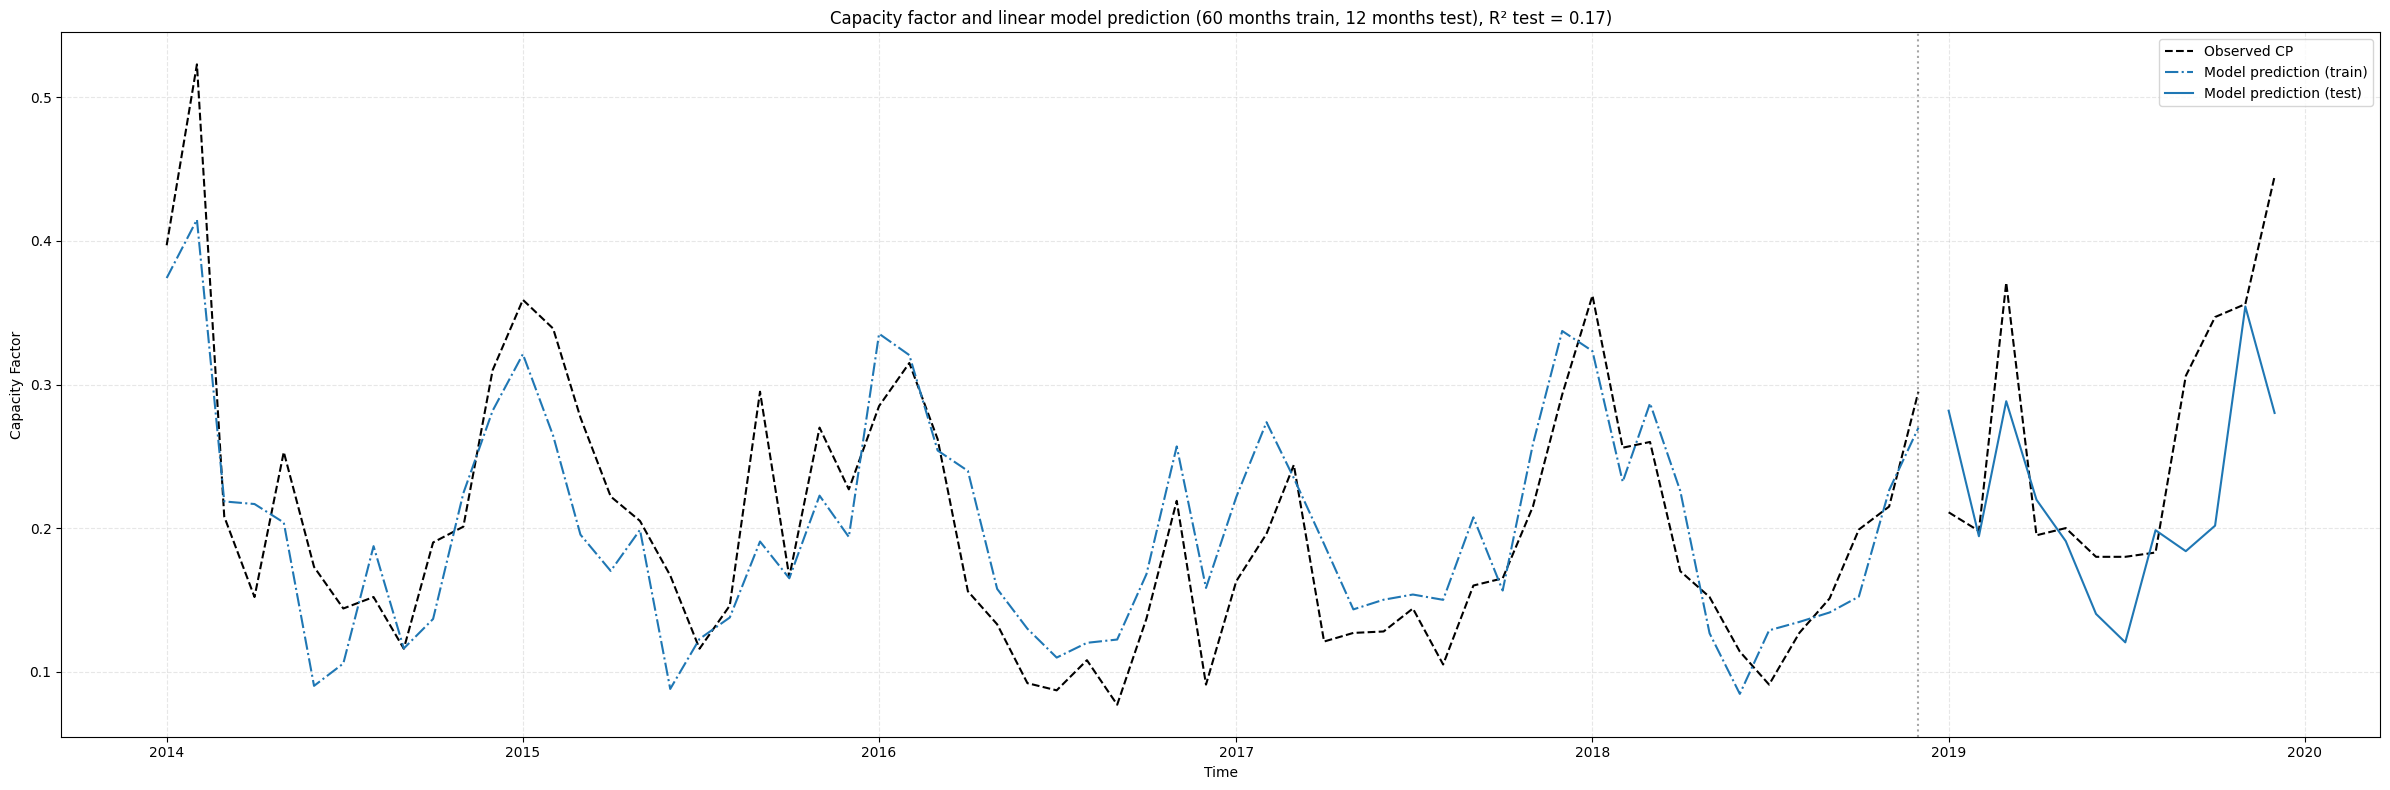

In [ ]:
df = df_dataset.sort_index().copy()

X_full = df.drop(columns=["capacity_factor"]).values
y_full = df["capacity_factor"].values
time_index = df.index

n_train = 60
X_train_raw = X_full[:n_train, :]
y_train = y_full[:n_train]

X_test_raw  = X_full[n_train:, :]
y_test = y_full[n_train:]

mean = X_train_raw.mean(axis=0)
std  = X_train_raw.std(axis=0)
std[std == 0] = 1e-8  

X_train = (X_train_raw - mean) / std
X_test  = (X_test_raw  - mean) / std


model = LinearRegression().fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)
plt.figure(figsize=(24,8))

plt.plot(
    time_index[:n_train],
    y_train,
    'k--',
    label='Observed CP'
)

plt.plot(
    time_index[n_train:],
    y_test,
    'k--'
)


plt.plot(
    time_index[:n_train],
    y_pred_train,
    color='C0',
    linestyle='-.',
    label='Model prediction (train)'
)


plt.plot(
    time_index[n_train:],
    y_pred_test,
    color='C0',
    linestyle='-',
    label='Model prediction (test)'
)


plt.axvline(time_index[n_train-1], color='gray', linestyle=':', alpha=0.7)


R2_test = model.score(X_test, y_test)
plt.xlabel("Time")
plt.ylabel("Capacity Factor")
plt.title(f"Capacity factor and linear model prediction (60 months train, 12 months test), R² test = {R2_test:.2f})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


#### 2.3.1 Training without zonal winds

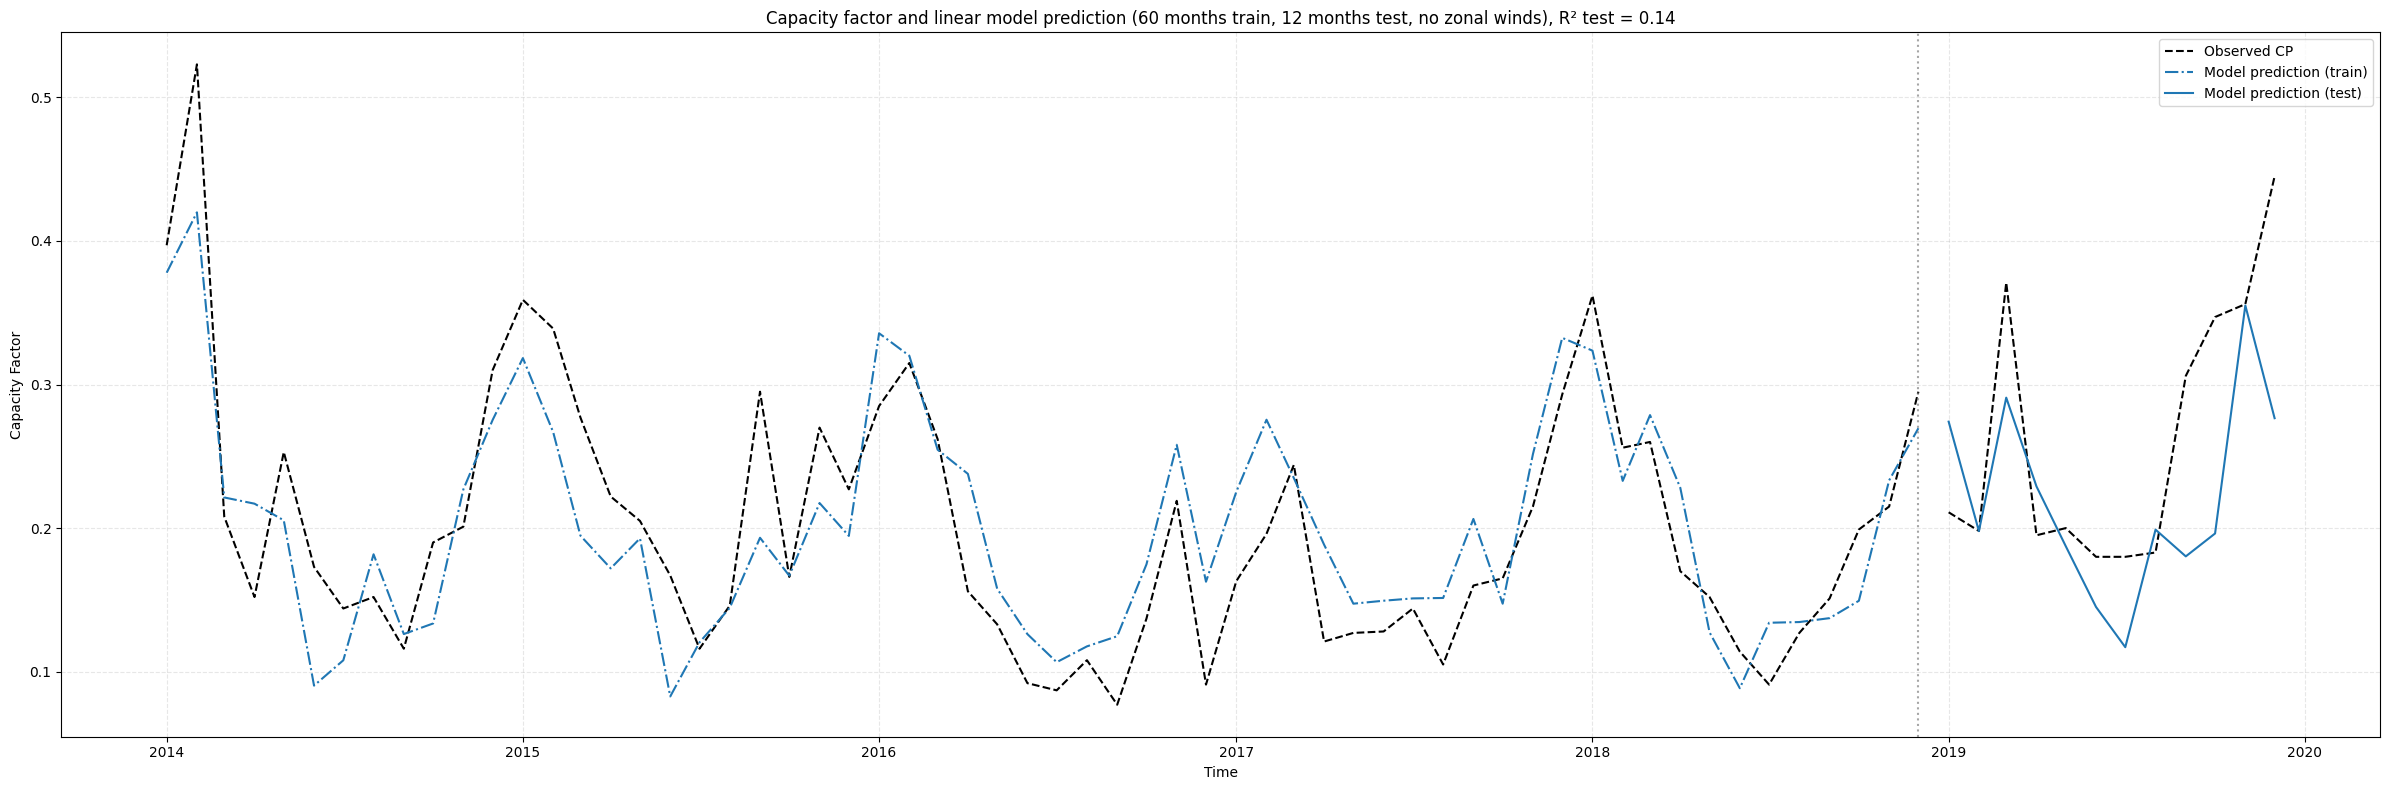

In [ ]:
df = df_dataset.sort_index().copy()

X_full = df.drop(columns=["capacity_factor", "zonal_wind", "upper_zonal_wind"]).values
y_full = df["capacity_factor"].values
time_index = df.index

n_train = 60
X_train_raw = X_full[:n_train, :]
y_train = y_full[:n_train]

X_test_raw  = X_full[n_train:, :]
y_test = y_full[n_train:]

mean = X_train_raw.mean(axis=0)
std  = X_train_raw.std(axis=0)
std[std == 0] = 1e-8  

X_train = (X_train_raw - mean) / std
X_test  = (X_test_raw  - mean) / std

model = LinearRegression().fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

plt.figure(figsize=(24,8))

plt.plot(
    time_index[:n_train],
    y_train,
    'k--',
    label='Observed CP'
)
plt.plot(
    time_index[n_train:],
    y_test,
    'k--'
)

plt.plot(
    time_index[:n_train],
    y_pred_train,
    color='C0',
    linestyle='-.',
    label='Model prediction (train)'
)

plt.plot(
    time_index[n_train:],
    y_pred_test,
    color='C0',
    linestyle='-',
    label='Model prediction (test)'
)

plt.axvline(time_index[n_train-1], color='gray', linestyle=':', alpha=0.7)

R2_test = model.score(X_test, y_test)

plt.xlabel("Time")
plt.ylabel("Capacity Factor")
plt.title(f"Capacity factor and linear model prediction (60 months train, 12 months test, no zonal winds), R² test = {R2_test:.2f}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


#### 2.3.2 Training with the last 4 years instead of 5 years

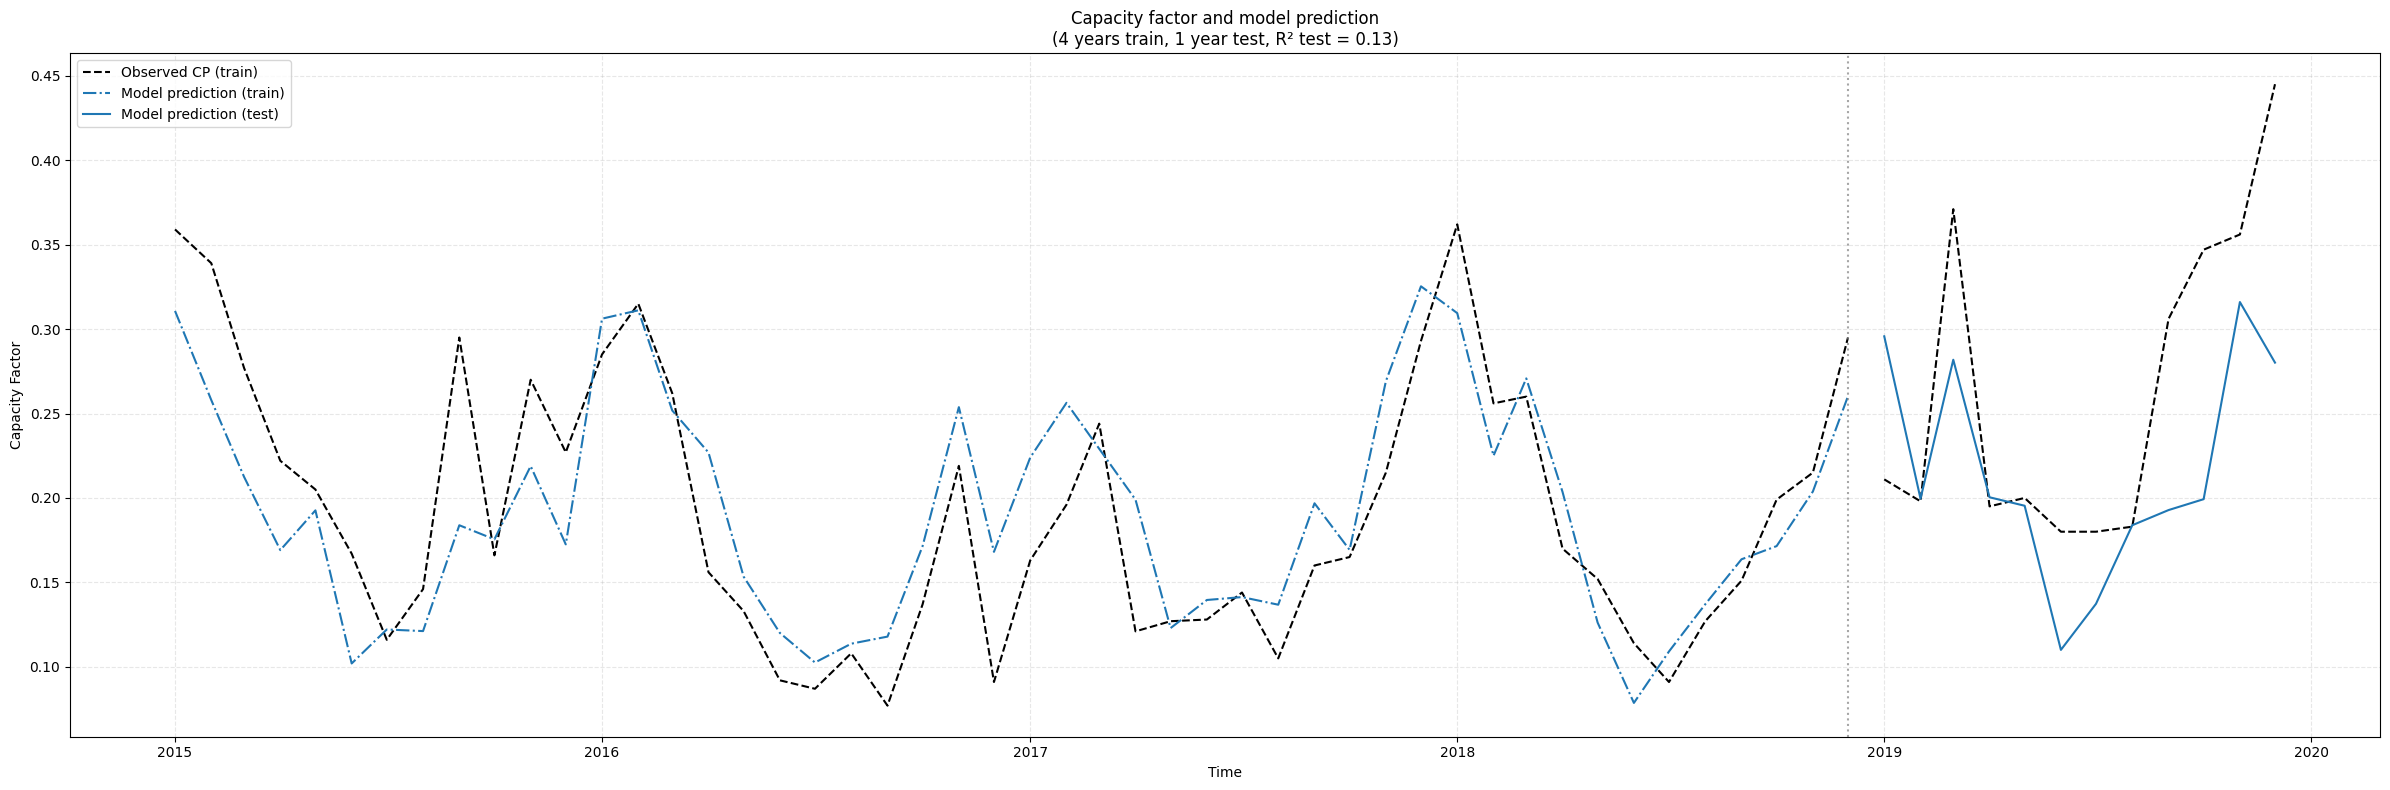

In [ ]:
df_sub = df_dataset.sort_index().loc['2015-01-01':].copy()

X_full = df_sub.drop(columns=["capacity_factor"]).values
y_full = df_sub["capacity_factor"].values
time_index = df_sub.index

n_months_per_year = 12
n_test  = 1 * n_months_per_year             
n_train = len(df_sub) - n_test             

X_train_raw = X_full[:n_train, :]
y_train = y_full[:n_train]

X_test_raw  = X_full[n_train:n_train + n_test, :]
y_test = y_full[n_train:n_train + n_test]

mean = X_train_raw.mean(axis=0)
std  = X_train_raw.std(axis=0)
std[std == 0] = 1e-8 

X_train = (X_train_raw - mean) / std
X_test  = (X_test_raw  - mean) / std

model = LinearRegression().fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

plt.figure(figsize=(24,8))

plt.plot(
    time_index[:n_train],
    y_train,
    'k--',
    label='Observed CP (train)'
)

plt.plot(
    time_index[n_train:],
    y_test,
    'k--',
)

plt.plot(
    time_index[:n_train],
    y_pred_train,
    color='C0',
    linestyle='-.',
    label='Model prediction (train)'
)

plt.plot(
    time_index[n_train:n_train + n_test],
    y_pred_test,
    color='C0',
    linestyle='-',
    label='Model prediction (test)'
)

plt.axvline(time_index[n_train-1], color='gray', linestyle=':', alpha=0.7)

R2_test = model.score(X_test, y_test)
plt.xlabel("Time")
plt.ylabel("Capacity Factor")
plt.title(f"Capacity factor and model prediction\n(4 years train, 1 year test, R² test = {R2_test:.2f})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


### 2.4. Ridge Regression


#### 2.4.1 Ridge Regression (L2 Regularization)

Ridge adds a penalty proportional to the **L2 norm** of the coefficients:

$$
\min_{\beta} ; \left( |y - X\beta|_2^2 + \alpha |\beta|_2^2 \right)
$$

where:

* $|\beta|_2 = \left( \sum_j \beta_j^2 \right)^{1/2}$
* $\alpha > 0$ is the regularization strength

The L2 penalty shrinks all coefficients toward zero but **never forces any of them to become exactly zero**.



#### 2.4.2 Lasso Regression (L1 Regularization)

Lasso adds a penalty proportional to the **L1 norm** of the coefficients:

$$
\min_{\beta} ; \left( |y - X\beta|_2^2 + \alpha |\beta|_1 \right)
$$

where:

* $|\beta|_1 = \sum_j |\beta_j|$

The L1 penalty encourages sparsity, meaning that **Lasso can force some coefficients to become exactly zero**, effectively performing feature selection.



### 2.5. Why the Norm Type and α Change Feature Importance

#### 2.5.1 Effect of the Regularization Term

$
\text{Loss} = \underbrace{|y - X\beta|*2^2}*{\text{fit to data}} + \underbrace{\alpha \cdot R(\beta)}_{\text{regularization}}
$

where:

* $R(\beta)$ is either the L1 or L2 norm
* α controls how much the regularization term influences the optimization


#### 2.5.2. How the Norms Affect β

##### 2.5.3. L2 norm (Ridge)

* Penalizes **large values** of $\beta_j$
* Encourages coefficients to be **small but not zero**
* Reduces variance and stabilizes the model under multicollinearity
* Keeps all features in the model but decreases their influence

##### 2.5.4. L1 norm (Lasso)

* Penalizes the **absolute value** of coefficients
* Has a geometric shape with **sharp corners** at zero
* These corners encourage coefficients to become **exactly zero**
* Performs automatic **feature selection**



### 2.6 Role of α

α scales the strength of the penalty:

* If α = 0, Ridge and Lasso reduce to ordinary least squares
* If α increases:

  * Ridge shrinks coefficients smoothly
  * Lasso forces more coefficients to zero

Thus, the choice of norm and the magnitude of α directly determine the final feature importance by controlling how the model balances accuracy vs. coefficient size.


### 2.7. Validation Curve for Ridge Regression

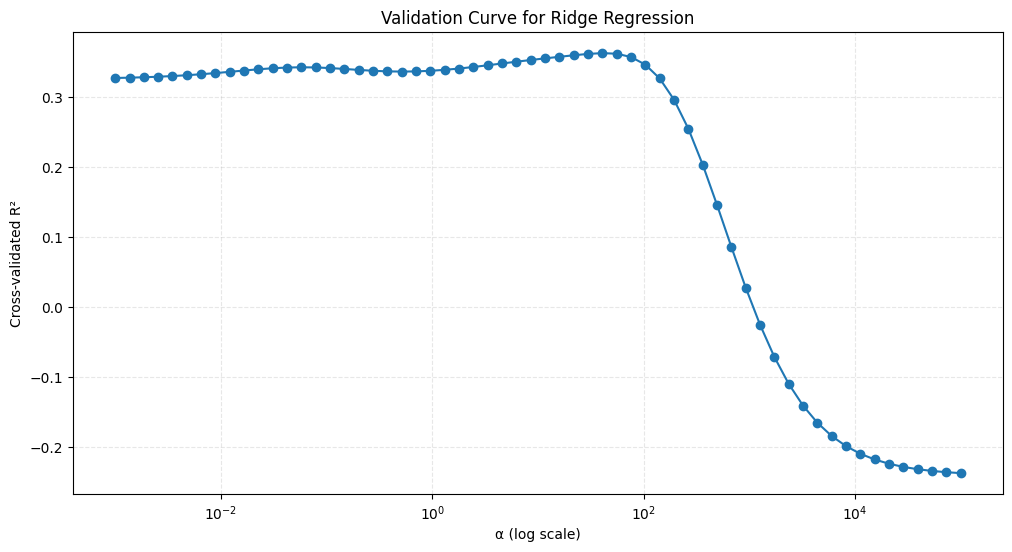

Best alpha found: 40.75392965871778
Best CV R²: 0.3633460863514698


In [ ]:
alphas = np.logspace(-3, 5, 60)  
r2_cv = []                       
coefs = []                      

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    
    scores = cross_val_score(ridge, X_train, y_train, cv=5)
    r2_cv.append(scores.mean())
    
    ridge.fit(X_train, y_train)
    coefs.append(ridge.coef_)

r2_cv = np.array(r2_cv)
coefs = np.array(coefs)

plt.figure(figsize=(12,6))
plt.plot(alphas, r2_cv, marker='o')
plt.xscale('log')
plt.xlabel("α (log scale)")
plt.ylabel("Cross-validated R²")
plt.title("Validation Curve for Ridge Regression")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

best_idx = np.argmax(r2_cv)
best_alpha = alphas[best_idx]
best_r2 = r2_cv[best_idx]

print("Best alpha found:", best_alpha)
print("Best CV R²:", best_r2)


In [ ]:
ols = LinearRegression().fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)
R2_ols = ols.score(X_test, y_test)

ridge_best = Ridge(alpha=best_alpha).fit(X_train, y_train)
y_pred_ridge = ridge_best.predict(X_test)
R2_ridge = ridge_best.score(X_test, y_test)

R2_ols, R2_ridge

(0.17273644578899372, 0.0029875982620685138)

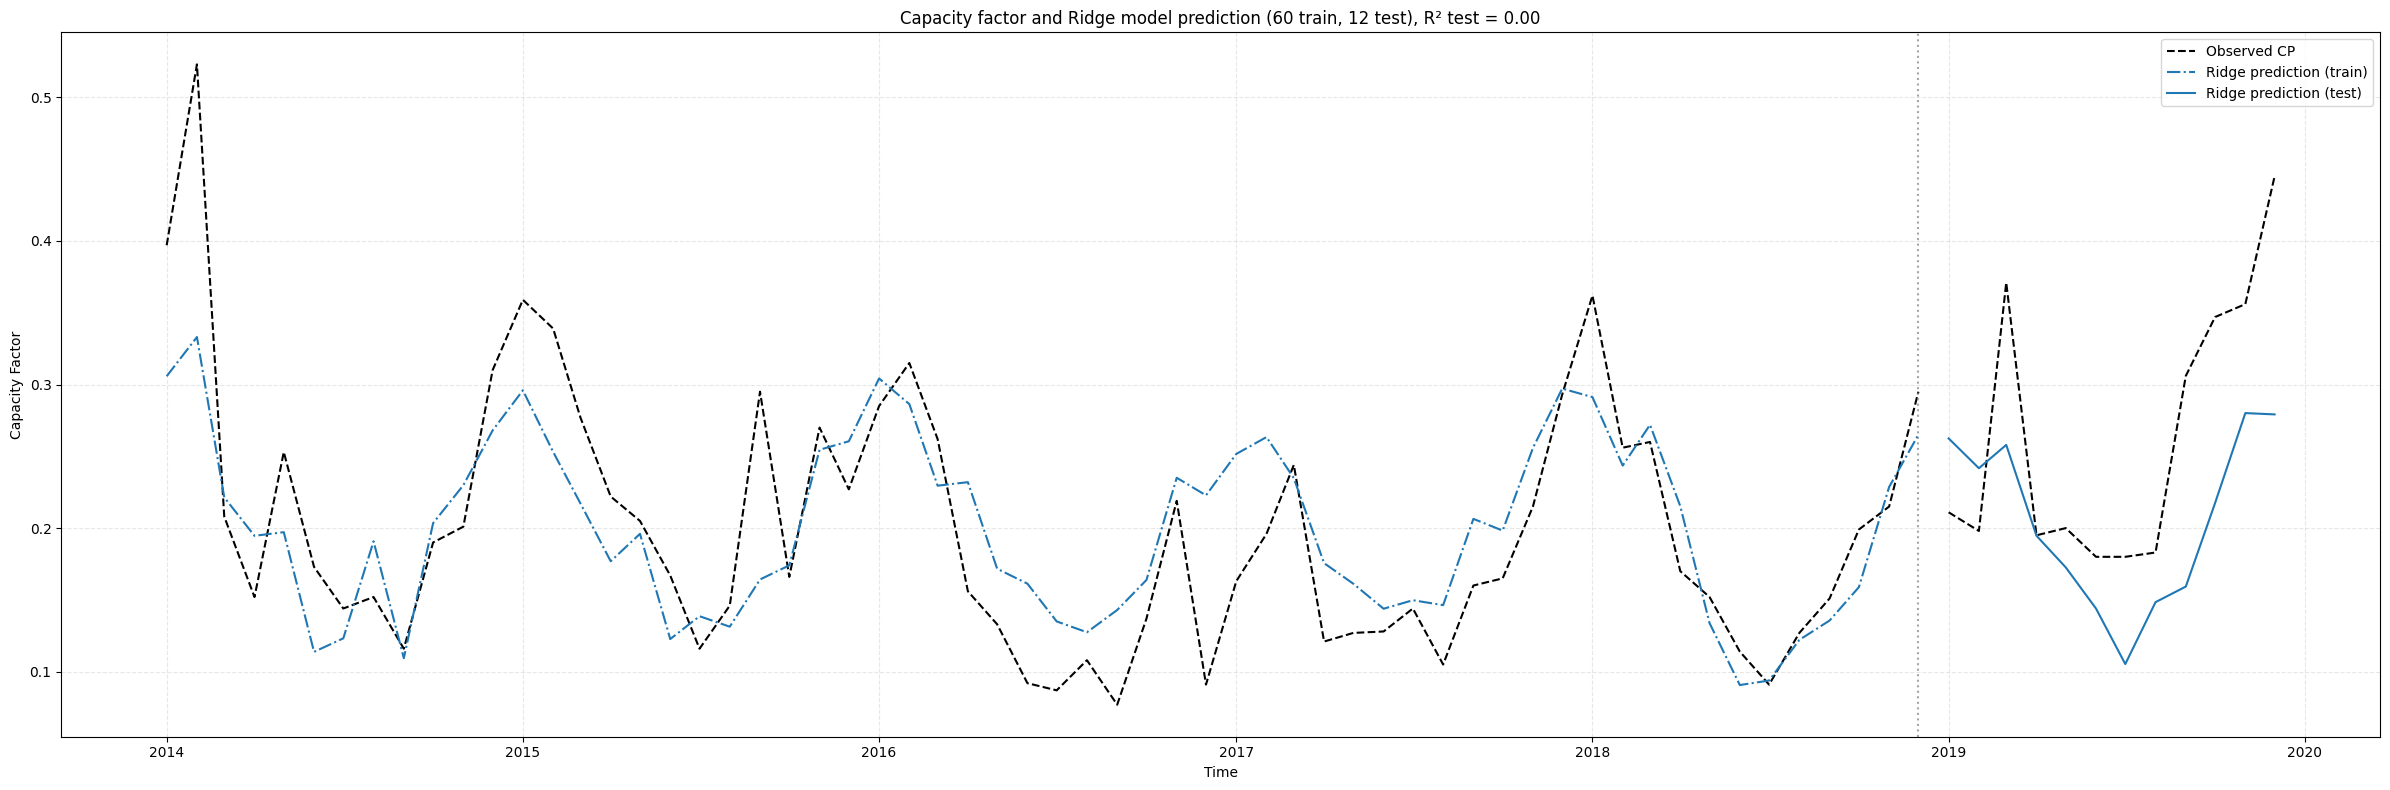

In [ ]:
df = df_dataset.sort_index().copy()

X_full = df.drop(columns=["capacity_factor"]).values
y_full = df["capacity_factor"].values
time_index = df.index

n_train = 60
X_train_raw = X_full[:n_train, :]
y_train = y_full[:n_train]

X_test_raw  = X_full[n_train:, :]
y_test = y_full[n_train:]

mean = X_train_raw.mean(axis=0)
std  = X_train_raw.std(axis=0)
std[std == 0] = 1e-8

X_train = (X_train_raw - mean) / std
X_test  = (X_test_raw  - mean) / std

ridge = Ridge(alpha=best_alpha)
ridge.fit(X_train, y_train)

y_pred_train = ridge.predict(X_train)
y_pred_test  = ridge.predict(X_test)

R2_test = ridge.score(X_test, y_test)

plt.figure(figsize=(24,8))

plt.plot(
    time_index[:n_train],
    y_train,
    'k--',
    label='Observed CP'
)
plt.plot(
    time_index[n_train:],
    y_test,
    'k--'
)

plt.plot(
    time_index[:n_train],
    y_pred_train,
    color='C0',
    linestyle='-.',
    label='Ridge prediction (train)'
)

plt.plot(
    time_index[n_train:],
    y_pred_test,
    color='C0',
    linestyle='-',
    label='Ridge prediction (test)'
)

plt.axvline(time_index[n_train-1], color='gray', linestyle=':', alpha=0.7)

plt.xlabel("Time")
plt.ylabel("Capacity Factor")
plt.title(f"Capacity factor and Ridge model prediction (60 train, 12 test), R² test = {R2_test:.2f}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


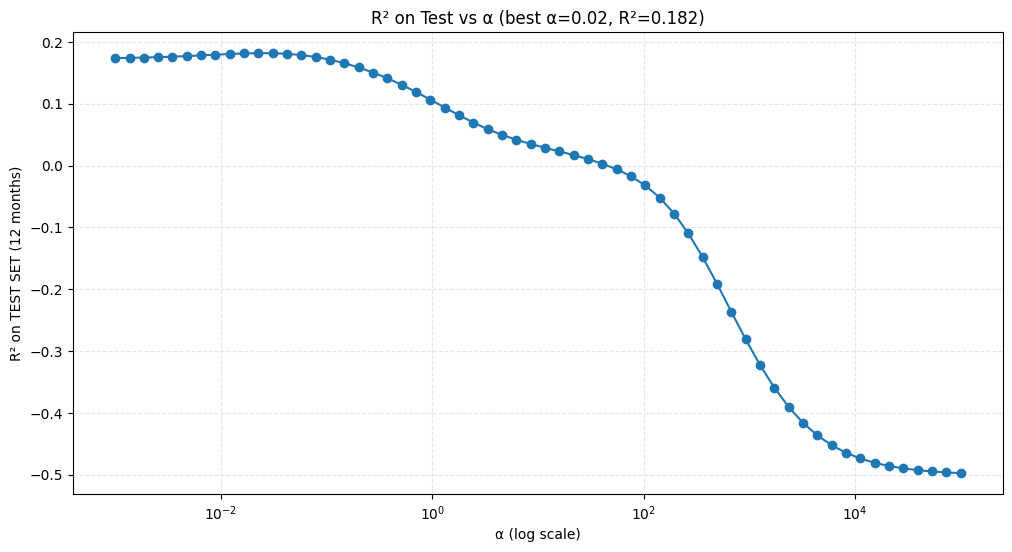

Best alpha according to TEST SET: 0.022695105366946685
Best R² on TEST SET: 0.18194437957624265


In [ ]:
alphas = np.logspace(-3, 5, 60)  
r2_test_list = []                

for alpha in alphas:
    
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    
    r2_test = ridge.score(X_test, y_test)
    r2_test_list.append(r2_test)

r2_test_list = np.array(r2_test_list)

$best_alpha_test = alphas[np.argmax(r2_test_list)]
best_r2_test = r2_test_list[np.argmax(r2_test_list)]

# plot
plt.figure(figsize=(12,6))
plt.plot(alphas, r2_test_list, marker='o')
plt.xscale('log')
plt.xlabel("α (log scale)")
plt.ylabel("R² on TEST SET (12 months)")
plt.title(f"R² on Test vs α (best α={best_alpha_test:.2f}, R²={best_r2_test:.3f})")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print("Best alpha according to TEST SET:", best_alpha_test)
print("Best R² on TEST SET:", best_r2_test)


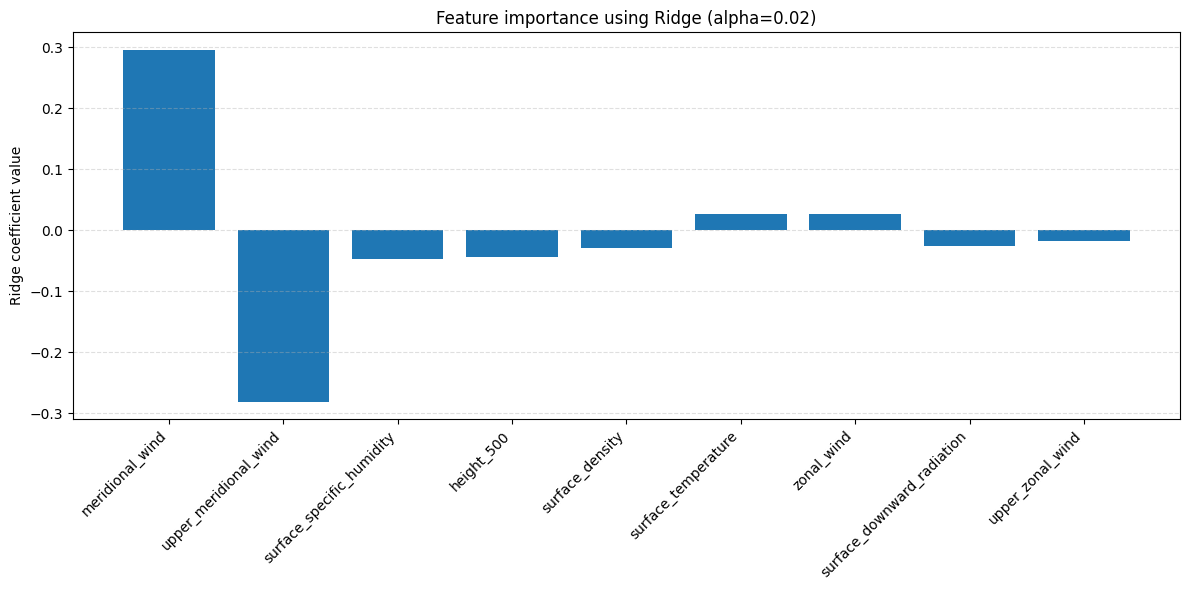

In [ ]:
feature_names = df_dataset.drop(columns=["capacity_factor"]).columns

ridge = Ridge(alpha=best_alpha_test)
ridge.fit(X_train, y_train)

coefs = ridge.coef_

idx_sorted = np.argsort(np.abs(coefs))[::-1]
coefs_sorted = coefs[idx_sorted]
features_sorted = feature_names[idx_sorted]

plt.figure(figsize=(12,6))
plt.bar(features_sorted, coefs_sorted)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Ridge coefficient value")
plt.title(f"Feature importance using Ridge (alpha={best_alpha_test:.2f})")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 2.8. Validation Curve for Lasso Regression

Best alpha (CV): 1.099e-02
Best CV R2: 0.385


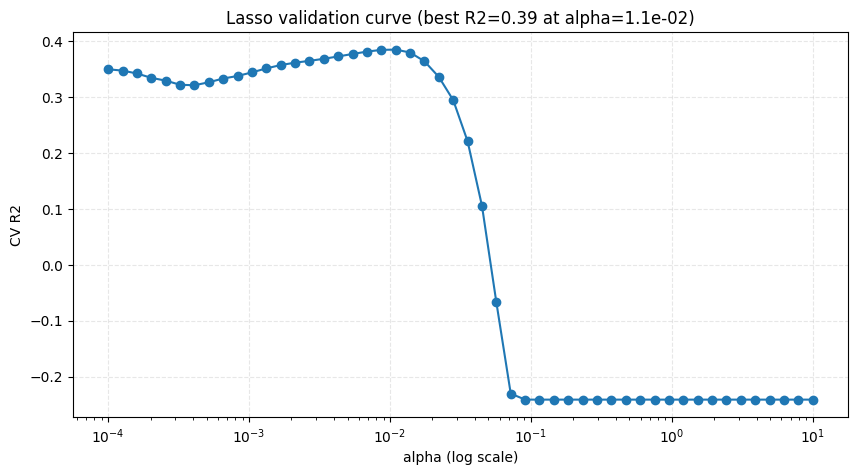

In [ ]:
reg_class = Lasso
kwargs_lasso = dict(max_iter=10000)

alphas = np.logspace(-4, 1, 50)
r2_validation = np.empty(alphas.shape)
coefs = np.empty((len(alphas), X_train.shape[1]))

for k, alpha in enumerate(alphas):
    reg = reg_class(alpha=alpha, **kwargs_lasso)
    
    scores = cross_val_score(reg, X_train, y_train, cv=5)
    r2_validation[k] = scores.mean()
    
    reg.fit(X_train, y_train)
    coefs[k] = reg.coef_

i_best = np.argmax(r2_validation)
alpha_best = alphas[i_best]
r2_best = r2_validation[i_best]
coefs_best = coefs[i_best]

print(f"Best alpha (CV): {alpha_best:.3e}")
print(f"Best CV R2: {r2_best:.3f}")

plt.figure(figsize=(10,5))
plt.plot(alphas, r2_validation, marker='o')
plt.xscale('log')
plt.xlabel("alpha (log scale)")
plt.ylabel("CV R2")
plt.title(f"Lasso validation curve (best R2={r2_best:.2f} at alpha={alpha_best:.1e})")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

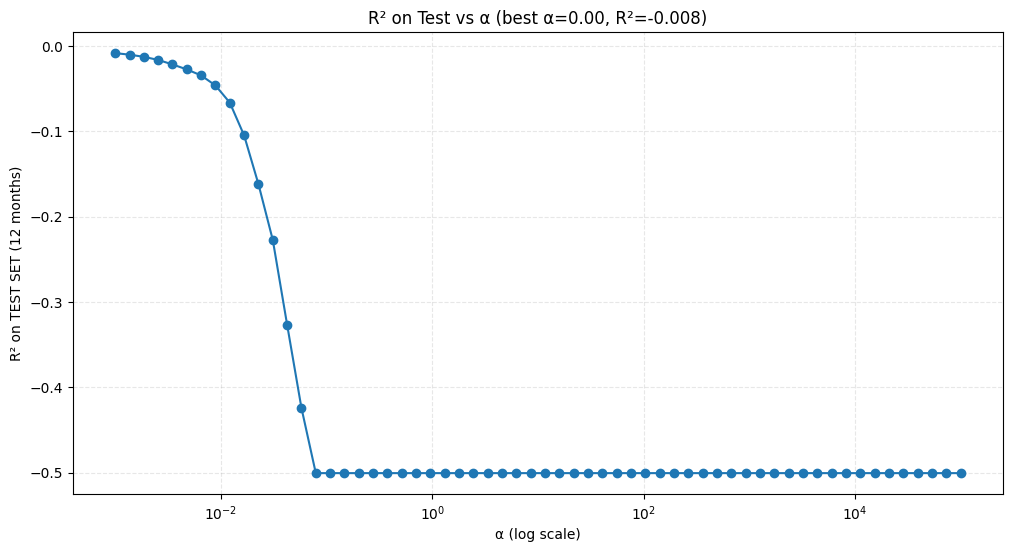

Best alpha according to TEST SET: 0.001
Best R² on TEST SET: -0.008140467369592619


In [ ]:
alphas = np.logspace(-3, 5, 60)
r2_test_list = []

for alpha in alphas:
    
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    
    r2_test = lasso.score(X_test, y_test)
    r2_test_list.append(r2_test)

r2_test_list = np.array(r2_test_list)

best_idx = np.argmax(r2_test_list)
best_alpha_test = alphas[best_idx]
best_r2_test = r2_test_list[best_idx]

plt.figure(figsize=(12, 6))
plt.plot(alphas, r2_test_list, marker='o')
plt.xscale('log')
plt.xlabel("α (log scale)")
plt.ylabel("R² on TEST SET (12 months)")
plt.title(f"R² on Test vs α (best α={best_alpha_test:.2f}, R²={best_r2_test:.3f})")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print("Best alpha according to TEST SET:", best_alpha_test)
print("Best R² on TEST SET:", best_r2_test)


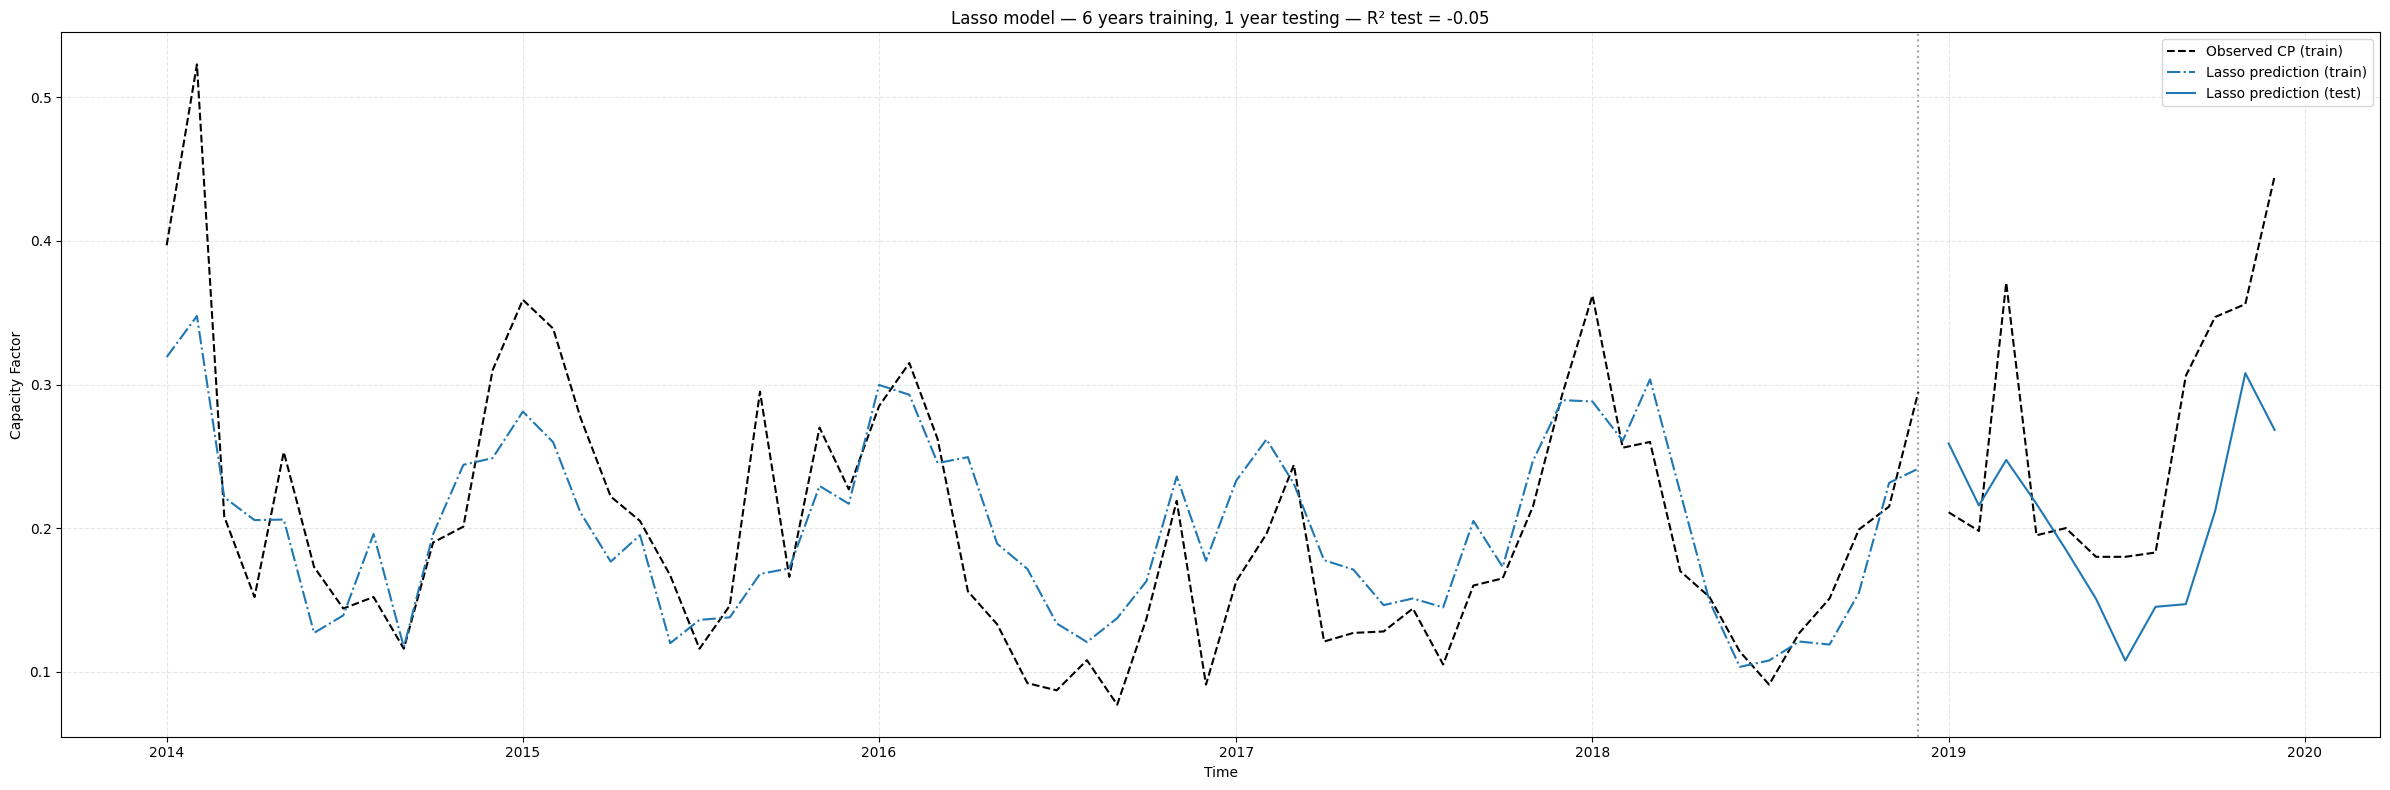

In [ ]:
df = df_dataset.sort_index().copy()

X_full = df.drop(columns=["capacity_factor"]).values
y_full = df["capacity_factor"].values
time_index = df.index

n_train = 60
X_train_raw = X_full[:n_train, :]
y_train = y_full[:n_train]

X_test_raw  = X_full[n_train:n_train+12, :]
y_test = y_full[n_train:n_train+12]

mean = X_train_raw.mean(axis=0)
std  = X_train_raw.std(axis=0)
std[std == 0] = 1e-8

X_train = (X_train_raw - mean) / std
X_test  = (X_test_raw  - mean) / std

lasso = Lasso(alpha=0.01, max_iter=100000)
lasso.fit(X_train, y_train)

y_pred_train = lasso.predict(X_train)
y_pred_test  = lasso.predict(X_test)

R2_test = lasso.score(X_test, y_test)

plt.figure(figsize=(24,8))

plt.plot(time_index[:n_train], y_train, 'k--', label='Observed CP (train)')
plt.plot(time_index[n_train:n_train+12], y_test, 'k--')

plt.plot(time_index[:n_train], y_pred_train, color='C0', linestyle='-.',
         label='Lasso prediction (train)')

plt.plot(time_index[n_train:n_train+12], y_pred_test, color='C0', linestyle='-',
         label='Lasso prediction (test)')

plt.axvline(time_index[n_train-1], color='gray', linestyle=':', alpha=0.7)

plt.xlabel("Time")
plt.ylabel("Capacity Factor")
plt.title(f"Lasso model — 6 years training, 1 year testing — R² test = {R2_test:.2f}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

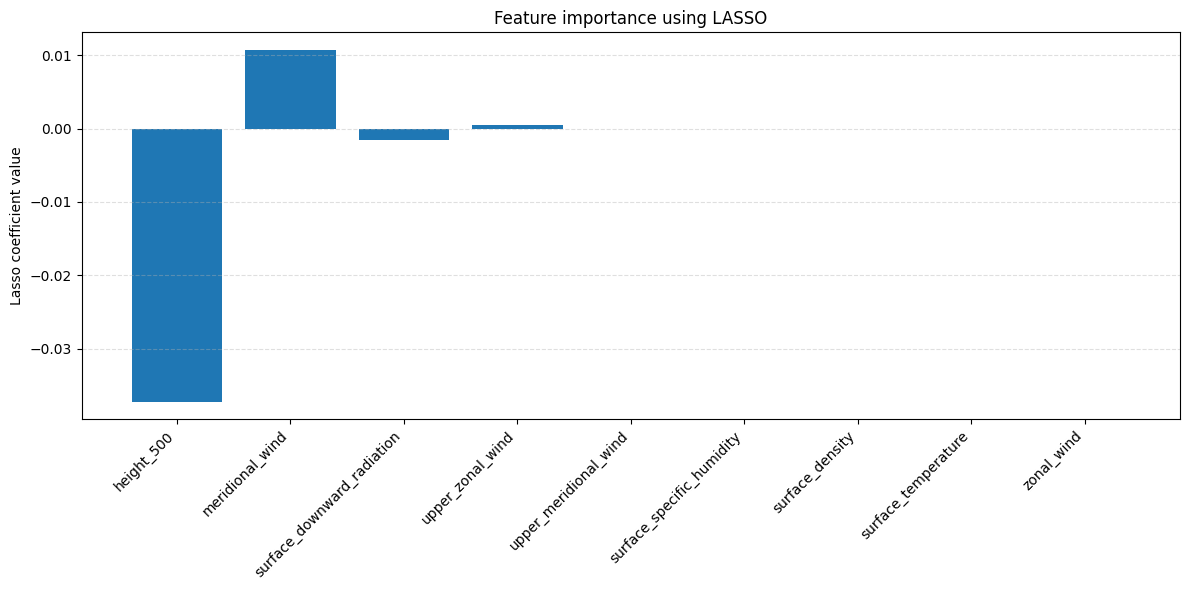

In [ ]:
feature_names = df_dataset.drop(columns=["capacity_factor"]).columns

lasso = Lasso(alpha=best_alpha_test, max_iter=100000)
lasso.fit(X_train, y_train)

coefs = lasso.coef_

idx_sorted = np.argsort(np.abs(coefs))[::-1]
coefs_sorted = coefs[idx_sorted]
features_sorted = feature_names[idx_sorted]

plt.figure(figsize=(12,6))
plt.bar(features_sorted, coefs_sorted)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Lasso coefficient value")
plt.title(f"Feature importance using LASSO")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

***
## Credit

[//]: # "This notebook is part of [E4C Interdisciplinary Center - Education](https://gitlab.in2p3.fr/energy4climate/public/education)."
Contributors include Bruno Deremble and Alexis Tantet.
Several slides and images are taken from the very good [Scikit-learn course](https://inria.github.io/scikit-learn-mooc/).

<br>

<div style="display: flex; height: 70px">
    
<img alt="Logo LMD" src="images/logos/logo_lmd.jpg" style="display: inline-block"/>

<img alt="Logo IPSL" src="images/logos/logo_ipsl.png" style="display: inline-block"/>

<img alt="Logo E4C" src="images/logos/logo_e4c_final.png" style="display: inline-block"/>

<img alt="Logo EP" src="images/logos/logo_ep.png" style="display: inline-block"/>

<img alt="Logo SU" src="images/logos/logo_su.png" style="display: inline-block"/>

<img alt="Logo ENS" src="images/logos/logo_ens.jpg" style="display: inline-block"/>

<img alt="Logo CNRS" src="images/logos/logo_cnrs.png" style="display: inline-block"/>
    
</div>

<hr>

<div style="display: flex">
    <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0; margin-right: 10px" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>
    <br>This work is licensed under a &nbsp; <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/">Creative Commons Attribution-ShareAlike 4.0 International License</a>.
</div>